# 06 — Writing Your Own Loss Function

**Time: ~20 minutes.** Builds on Notebook 03.

## What you'll learn

The losses shipped in `midas_integrate_v2.losses` (`EtaUniformityLoss`,
`PeakPositionLoss`, `ProfileMSELoss`, `GaussianPriorLoss`,
`MultiImageLoss`, `BatchedSpecLoss`) cover the common cases. But your
calibration problem may need something custom: a constraint specific
to your sample, a robust loss against outlier pixels, or a regulariser
that ties Lsd to wavelength via a known beam energy. This notebook
shows how to write one.

By the end you will have:

1. Written a **`PeakSharpnessLoss`** that maximises peak height /
   width — narrow rings ⇔ good calibration.
2. Combined it with `EtaUniformityLoss` via a weighted sum.
3. Used the result in a multi-parameter refinement loop.
4. Learned the three rules that any custom loss must follow to keep
   autograd working: **(a) operate on tensors, (b) preserve the graph,
   (c) return a scalar**.

## The three rules

A loss function for `midas-integrate-v2` is just any callable that
takes the integrated 2-D array `(n_eta, n_r)` (and optionally the
`spec` and other tensors) and returns a `torch.Tensor` of shape `()`.
Three rules:

1. **Use torch ops, not numpy / scalar Python ops** on tensors that
   carry gradient. `np.sum(int2d.numpy())` *breaks* the graph;
   `int2d.sum()` keeps it.
2. **Don't `.detach()` the gradient path** unless you mean it. Common
   pitfall: weighting by `int2d.detach().abs()` to make the weights
   "constant" — that does the right thing for the weights but kills
   gradient through them.
3. **Return a scalar tensor** so `.backward()` works without a
   `gradient=` arg.

Anything else (smoothness, robustness, physical priors) is up to you.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

HERE = Path.cwd() if Path.cwd().name == "notebooks" else Path("notebooks")
REPO = HERE.resolve().parents[2]
DATA = REPO / "FF_HEDM" / "Example" / "Calibration"

from midas_integrate_v2 import (
    spec_from_v1_paramstest,
    integrate_with_corrections,
    EtaUniformityLoss,
)


## Step 1 — A custom loss: PeakSharpnessLoss

A perfectly calibrated geometry produces *narrow* rings (each ring
hits a small range of R bins). When BC is wrong, the ring spreads
out — same ring lands at slightly different R for different η, so
the integrated profile widens.

**Idea**: maximise (peak height) / (peak width). Bigger ratio ⇒ sharper
peak ⇒ better calibration.


In [2]:
class PeakSharpnessLoss(nn.Module):
    """Negative max-over-FWHM ratio for peaks in a fixed R window.

    Parameters
    ----------
    r_band_indices :
        R-bin indices defining the window around an expected ring.
    target_R_px :
        Predicted ring centre (px). Used for the FWHM measurement.

    The loss is -peak_height / (peak_FWHM + 1e-6); minimising it
    maximises the height/width ratio.
    """
    def __init__(self, r_band_indices, target_R_px, RMin, RBinSize):
        super().__init__()
        self.r_band = torch.tensor(list(r_band_indices), dtype=torch.long)
        self.target_R = float(target_R_px)
        self.RMin = float(RMin); self.RBinSize = float(RBinSize)

    def forward(self, int2d):
        # 1-D profile from 2-D
        prof = int2d.mean(dim=0)
        # restrict to the window
        win = prof.index_select(0, self.r_band.to(prof.device))
        peak = win.max()
        # FWHM ≈ Σ (intensity > 0.5 max) bins
        half = peak * 0.5
        above = (win > half).to(win.dtype)
        fwhm_bins = above.sum() + 1e-6
        # height/width — return negative because we minimise
        return -peak / (fwhm_bins * self.RBinSize)


# Quick test the loss is callable + differentiable
spec = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=True)
spec.RBinSize = 2.0; spec.EtaBinSize = 5.0
n_r = spec.n_r_bins
r_axis = spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)
band = (r_axis > 200) & (r_axis < 230)
band_idx = np.where(band)[0].tolist()

loss = PeakSharpnessLoss(band_idx, target_R_px=211.0,
                          RMin=spec.RMin, RBinSize=spec.RBinSize)
print(f"PeakSharpnessLoss built; band has {len(band_idx)} R bins")


PeakSharpnessLoss built; band has 15 R bins


## Step 2 — Run a refinement using the custom loss

Same pattern as notebook 03: load image, perturb BC_y, call
`integrate_with_corrections`, hand the output to our custom loss,
backward + step.


In [3]:
import tifffile
img_raw = tifffile.imread(
    DATA / "CeO2_Pil_100x100_att000_650mm_71p676keV_001956.tif"
).astype(np.float64)
dark = tifffile.imread(
    DATA / "dark_CeO2_Pil_100x100_att000_650mm_71p676keV_001975.tif"
).astype(np.float64)
if dark.ndim == 3:
    dark = dark.mean(axis=0)
img = torch.from_numpy(np.clip(img_raw - dark, 0, None))

BC_y_true = float(spec.BC_y.detach())
spec.BC_y = torch.tensor(BC_y_true + 1.0, dtype=torch.float64,
                          requires_grad=True)
print(f"Starting BC_y: {float(spec.BC_y.detach()):.4f}, "
      f"true: {BC_y_true:.4f}")

opt = torch.optim.Adam([spec.BC_y], lr=0.05)
hist = {"BC_y": [float(spec.BC_y.detach())], "loss": []}
for step in range(60):
    opt.zero_grad()
    int2d = integrate_with_corrections(img, spec)
    L = loss(int2d)
    L.backward()
    opt.step()
    hist["BC_y"].append(float(spec.BC_y.detach()))
    hist["loss"].append(float(L))

print(f"Final BC_y: {hist['BC_y'][-1]:.4f} (true {BC_y_true:.4f})")
print(f"Loss: {hist['loss'][0]:.4e} → {hist['loss'][-1]:.4e}")


Starting BC_y: 686.4855, true: 685.4855


/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/ipykernel_60814/3973246025.py:27: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  hist["loss"].append(float(L))


Final BC_y: 685.5028 (true 685.4855)
Loss: -8.2274e+05 → -1.0341e+06


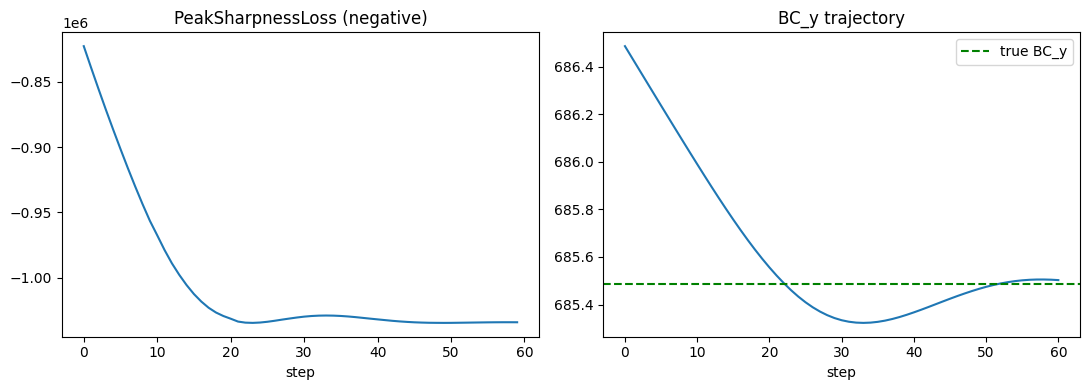

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist["loss"]); axes[0].set_title("PeakSharpnessLoss (negative)")
axes[0].set_xlabel("step")
axes[1].plot(hist["BC_y"]); axes[1].axhline(BC_y_true, color="g", ls="--",
                                            label="true BC_y")
axes[1].set_title("BC_y trajectory"); axes[1].set_xlabel("step")
axes[1].legend()
plt.tight_layout(); plt.show()


**You should see** the loss decreasing (becoming more negative ⇒ ratio
increasing ⇒ peak getting sharper) and BC_y converging to truth. The
sharpness loss carries different curvature than `EtaUniformityLoss`,
so the trajectory shape will differ from notebook 03.

## Step 3 — Combine multiple losses

In practice you almost always combine losses: a *data* loss (uses
the image) + a *prior* loss (penalises drift from a known good
geometry). Adding them as `α · L_data + β · L_prior` is just a torch
sum.


In [5]:
from midas_integrate_v2 import GaussianPriorLoss

# Wavelength prior: trust beamline mono to ±0.001 Å
prior = GaussianPriorLoss({
    "Wavelength": (float(spec.Wavelength.detach()), 0.001),
    "Lsd":        (657_437.0, 1000.0),       # ±1 mm
})

eta_loss = EtaUniformityLoss(r_indices=band_idx, intensity_floor=1.0)

# Reset BC_y to perturbed
spec.BC_y = torch.tensor(BC_y_true + 1.0, dtype=torch.float64,
                          requires_grad=True)
spec.Lsd = spec.Lsd.detach().clone().requires_grad_(True)

opt = torch.optim.Adam([spec.BC_y, spec.Lsd], lr=0.05)
combined_history = {"BC_y": [float(spec.BC_y.detach())],
                     "Lsd":  [float(spec.Lsd.detach())],
                     "L_data": [], "L_prior": [], "L_total": []}
for step in range(60):
    opt.zero_grad()
    int2d = integrate_with_corrections(img, spec)
    L_data  = eta_loss(int2d)
    L_prior = prior(spec)
    L_total = L_data + 0.0001 * L_prior      # weight ratio is a hyperparam
    L_total.backward()
    opt.step()
    combined_history["BC_y"].append(float(spec.BC_y.detach()))
    combined_history["Lsd"].append(float(spec.Lsd.detach()))
    combined_history["L_data"].append(float(L_data))
    combined_history["L_prior"].append(float(L_prior))
    combined_history["L_total"].append(float(L_total))

print(f"BC_y: start {combined_history['BC_y'][0]:.3f}, "
      f"end {combined_history['BC_y'][-1]:.3f}, true {BC_y_true:.3f}")
print(f"Lsd:  start {combined_history['Lsd'][0]:.0f}, "
      f"end {combined_history['Lsd'][-1]:.0f}")


BC_y: start 686.485, end 685.424, true 685.485
Lsd:  start 657437, end 657438


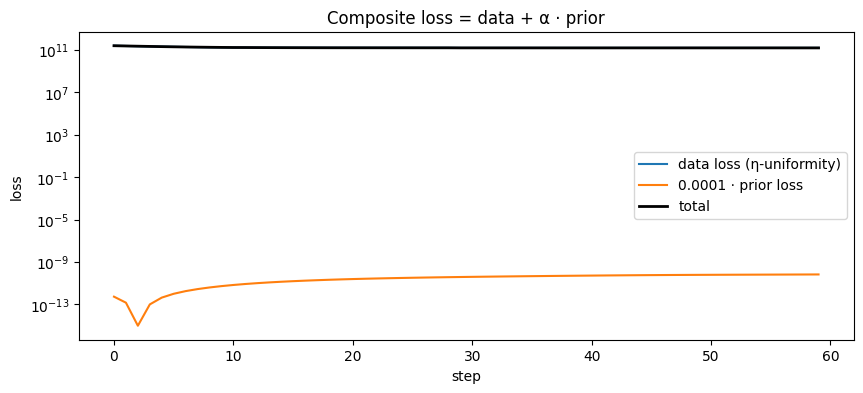

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(combined_history["L_data"], label="data loss (η-uniformity)")
ax.plot(np.array(combined_history["L_prior"]) * 0.0001, label="0.0001 · prior loss")
ax.plot(combined_history["L_total"], label="total", lw=2, color="k")
ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.set_yscale("log")
ax.legend(); ax.set_title("Composite loss = data + α · prior")
plt.show()


**The prior keeps Lsd from drifting** to bad values (which would
trade off against BC_y errors and cause divergence). Tune the weight
α (here `0.0001`) to balance how much you trust the data vs the prior.
A small α lets the data dominate; a large α pins the parameters near
the prior mean.

## Step 4 — A robust (Huber) variant

Real images have outlier pixels (cosmic rays, hot pixels, single-event
upsets). MSE-style losses are *quadratic* in residual — outliers
dominate. The Huber loss is quadratic for small residuals and linear
for large ones.


In [7]:
class HuberProfileLoss(nn.Module):
    """Huber loss between an integrated 1-D profile and a reference.

    delta : float
        Threshold below which the loss is quadratic (MSE-like);
        above which it's linear (robust to outliers).
    """
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = float(delta)

    def forward(self, int2d, spec, reference_1d):
        prof = int2d.mean(dim=0)
        if prof.shape != reference_1d.shape:
            raise ValueError(f"profile/reference shape mismatch")
        residual = (prof - reference_1d).abs()
        # quadratic for r < δ, linear for r ≥ δ
        quad = 0.5 * residual ** 2
        lin  = self.delta * (residual - 0.5 * self.delta)
        return torch.where(residual < self.delta, quad, lin).mean()


# Smoke test
prof = torch.randn(spec.n_r_bins, dtype=torch.float64) * 5
target = torch.zeros_like(prof)
fake_int2d = prof.unsqueeze(0).repeat(spec.n_eta_bins, 1)
huber = HuberProfileLoss(delta=2.0)
L = huber(fake_int2d, spec, target)
print(f"HuberProfileLoss demo: L = {float(L):.4f}")


HuberProfileLoss demo: L = 5.9658


## Common pitfalls when writing custom losses

1. **Accidental graph break**: `int2d.numpy()`, `.detach()`,
   `int(some_tensor)`, `float(some_tensor)`. If your gradient is
   suddenly all zero, look for these.
2. **In-place ops on a tensor with grad**: `prof[5] = 0` or `prof *=
   2.0` modify in-place and confuse autograd. Use `.clone()` first
   or assemble via `torch.cat` / `torch.stack`.
3. **Returning a Python float instead of a tensor**: `.backward()`
   needs a tensor. `loss = float(L)` then `.backward()` ⇒ AttributeError.
4. **Loss not actually depending on the parameter**: if your loss
   masks out all bins, gradient w.r.t. params is zero. Check via
   `torch.autograd.grad(L, spec.BC_y)` — if it's zero/NaN you have a
   masking bug.

## Try it yourself

1. **Write a `RingCountLoss`** that counts how many R bins lie within
   3% of a predicted ring centre and returns negative count (so
   minimisation maximises rings hit). What goes wrong if you use
   `(prof > 0.5).sum()` directly? (Hint: integer cast kills gradient.)
2. **Write a smoothness regulariser** for the spec parameters:
   `L_smooth = (BC_y_now - BC_y_seed)².mean() + (Lsd_now - Lsd_seed)².mean()`.
   Add it with weight 1e-3 to your data loss. Does the refinement
   stay closer to the seed?
3. **Use `BatchedSpecLoss(your_custom_loss)`** to apply your loss to
   a stack of N images at once. The convention is your loss takes
   `(int2d, spec, target=None)` and returns a scalar.

## Next: 07 — Bayesian Calibration with Laplace Uncertainty

Refinement gives you a *point estimate* of geometry. Beamline reality
has noise — you want the *uncertainty* too. Notebook 07 shows how
to wrap a refined geometry in a Laplace approximation and get
1σ error bars on each parameter.
